# Which airports experience the highest, the lowest, and most consistent delay rates?

In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_AT = pd.read_excel("datasets/AirportTraffic.xlsx")
df_TIn = pd.read_excel("datasets/Taxi-In_Additional_Time.xlsx")
df_TOut = pd.read_excel("datasets/Taxi-Out_Additional_Time.xlsx")
df_AAD = pd.read_excel("datasets/AA_ATFM_Delay.xlsx")
df_AP = pd.read_excel("datasets/Airports_Punctuality.xlsx")
df_AID= pd.read_excel("datasets/Airport_IATA_delays_airline_reported.xlsx")
df_PDD = pd.read_excel("datasets/Primary_departure_Delay_Causes_AP.xlsx")
df_FPD = pd.read_excel("datasets/Flight_Punctuality_Distribution.xlsx")
df_Ageo = pd.read_csv("datasets/Airport_Geo2.csv", quoting=3, on_bad_lines="skip")

In [6]:
df_top20 = (
    df_AT.groupby("APT_ICAO")[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]] #Group by airport code
    .sum().sort_values(by="FLT_TOT_1",ascending=False) #Sum the values for each code of the 3 columns indicated
    .head(20).reset_index()) #Change "20" to change the number of airports analysed

# Adding airport's city name and state from original dataset
df_top20 = (df_top20.merge(df_AT[["APT_ICAO", "APT_NAME", "STATE_NAME", "YEAR", "MONTH_NUM"]]
                           .drop_duplicates(), on="APT_ICAO", how="left"))

airports_code_list = df_top20["APT_ICAO"].tolist()

In [8]:
df_month = df_AAD[df_AAD["APT_ICAO"].isin(airports_code_list)].copy()

# Calculate the mean number of delayed flights and delay minutes for each airport.
monthly_means = (
    df_month.groupby(["APT_ICAO", "YEAR", "MONTH_NUM"])
    .agg(
        Mean_delayed_flights=("FLT_ARR_1_DLY", "mean"),
        Mean_delay_minutes=("DLY_APT_ARR_1", "mean")
    )
    .reset_index()
)

# The dataset df_AAD had different columns with years, month names and month numbers. 
# We create one column with the year and month in the form of yyyy-mm.
# In the second line, we delete the seperate columns with year, month numbers and number of days in the month.
monthly_means["YEAR_MONTH"] = monthly_means["YEAR"].astype(str) + "-" + monthly_means["MONTH_NUM"].astype(str).str.zfill(2)
monthly_means = monthly_means.drop(columns=["YEAR", "MONTH_NUM"])

# From the df_AAD dataset we derive the airportname and statename. We add this information in the dataframe.
df_monthly_means = monthly_means.merge(
    df_AAD[["APT_ICAO", "APT_NAME", "STATE_NAME"]],
    on="APT_ICAO",
    how="left"
)

df_monthly_means = df_monthly_means.drop_duplicates()

# Orden de kolommen netjes
df_monthly_means = df_monthly_means[[
    "APT_ICAO",
    "APT_NAME",
    "STATE_NAME",
    "YEAR_MONTH",
    "Mean_delayed_flights",
    "Mean_delay_minutes"
]]

print(df_monthly_means)

       APT_ICAO   APT_NAME STATE_NAME YEAR_MONTH  Mean_delayed_flights  \
0          EDDF  Frankfurt    Germany    2023-01             91.500000   
731        EDDF  Frankfurt    Germany    2023-02             23.000000   
1462       EDDF  Frankfurt    Germany    2023-03             58.333333   
2193       EDDF  Frankfurt    Germany    2023-04             48.142857   
2924       EDDF  Frankfurt    Germany    2023-05            218.500000   
...         ...        ...        ...        ...                   ...   
347177     LTFM   Istanbul    Türkiye    2024-08             99.333333   
347908     LTFM   Istanbul    Türkiye    2024-09             57.000000   
348639     LTFM   Istanbul    Türkiye    2024-10             83.000000   
349370     LTFM   Istanbul    Türkiye    2024-11            114.500000   
350101     LTFM   Istanbul    Türkiye    2024-12                   NaN   

        Mean_delay_minutes  
0              2523.500000  
731             417.000000  
1462            929.3333

Now we calculate the delay rates for each month for each airport

In [32]:
df_with_monthly_delay_rates = df_monthly_means.copy()

# We calculate the number of arrivals for each month at each airport
df_AAD_monthly = df_AAD.groupby(["APT_ICAO", "YEAR", "MONTH_NUM"]).agg(
    Total_flights=("FLT_ARR_1", "sum"),
    Total_delayed_flights=("FLT_ARR_1_DLY", "sum")
).reset_index()

df_AAD_monthly["YEAR_MONTH"] = df_AAD_monthly["YEAR"].astype(str) + "-" + df_AAD_monthly["MONTH_NUM"].astype(str).str.zfill(2)

df_with_monthly_delay_rates = df_monthly_means.merge(
    df_AAD_monthly,
    on=["APT_ICAO", "YEAR_MONTH"],
    how="left"
)

# Delay rate based on the number of flights, each month.
df_with_monthly_delay_rates["Delay_rate_flights"] = (
    df_with_monthly_delay_rates["Total_delayed_flights"] / df_with_monthly_delay_rates["Total_flights"] * 100
)

# We remove the MONTH_NUM column as YEAR_MONTH is already in the dataframe df_with_monthly_delay_rates.
df_with_monthly_delay_rates = df_with_monthly_delay_rates.drop(columns=["MONTH_NUM"])

print(df_with_monthly_delay_rates)

    APT_ICAO   APT_NAME STATE_NAME YEAR_MONTH  Mean_delayed_flights  \
0       EDDF  Frankfurt    Germany    2023-01             91.500000   
1       EDDF  Frankfurt    Germany    2023-02             23.000000   
2       EDDF  Frankfurt    Germany    2023-03             58.333333   
3       EDDF  Frankfurt    Germany    2023-04             48.142857   
4       EDDF  Frankfurt    Germany    2023-05            218.500000   
..       ...        ...        ...        ...                   ...   
475     LTFM   Istanbul    Türkiye    2024-08             99.333333   
476     LTFM   Istanbul    Türkiye    2024-09             57.000000   
477     LTFM   Istanbul    Türkiye    2024-10             83.000000   
478     LTFM   Istanbul    Türkiye    2024-11            114.500000   
479     LTFM   Istanbul    Türkiye    2024-12                   NaN   

     Mean_delay_minutes  YEAR  Total_flights  Total_delayed_flights  \
0           2523.500000  2023          14832                  183.0   
1    

In [17]:
consistency = (
    df_with_monthly_delay_rates.groupby("APT_NAME")["Delay_rate_flights"]
    .agg(["mean", "std"])
    .reset_index()
)

consistency["cv"] = consistency["std"] / consistency["mean"]
consistency = consistency.sort_values("cv")

# Sort airports on consistency of delay rates. For later, to order the boxplots
airports = consistency["APT_NAME"].values

In [30]:
# We calculate the mean and std per airport per year
yearly_stats = (
    df_month.groupby(["APT_ICAO", "APT_NAME", "STATE_NAME", "YEAR"])
    .agg(
        Mean_delayed_flights=("FLT_ARR_1_DLY", "mean"),
        Std_delayed_flights=("FLT_ARR_1_DLY", "std"),
        Mean_delay_minutes=("DLY_APT_ARR_1", "mean"),
        Std_delay_minutes=("DLY_APT_ARR_1", "std"),
    )
    .reset_index()
)

# We create separate dataframes for 2023 and 2024
mean_std_23 = yearly_stats[yearly_stats["YEAR"] == 2023].copy()
mean_std_24 = yearly_stats[yearly_stats["YEAR"] == 2024].copy()

print(mean_std_23)
print(mean_std_24)

   APT_ICAO                 APT_NAME      STATE_NAME  YEAR  \
0      EDDF                Frankfurt         Germany  2023   
2      EDDM                   Munich         Germany  2023   
4      EGKK         London - Gatwick  United Kingdom  2023   
6      EGLL        London - Heathrow  United Kingdom  2023   
8      EHAM     Amsterdam - Schiphol     Netherlands  2023   
10     EIDW                   Dublin         Ireland  2023   
12     EKCH     Copenhagen - Kastrup         Denmark  2023   
14     ENGM        Oslo - Gardermoen          Norway  2023   
16     LEBL                Barcelona           Spain  2023   
18     LEMD         Madrid - Barajas           Spain  2023   
20     LEPA        Palma de Mallorca           Spain  2023   
22     LFPG  Paris-Charles-de-Gaulle          France  2023   
24     LGAV                   Athens          Greece  2023   
26     LIRF         Rome - Fiumicino           Italy  2023   
28     LOWW                   Vienna         Austria  2023   
30     L

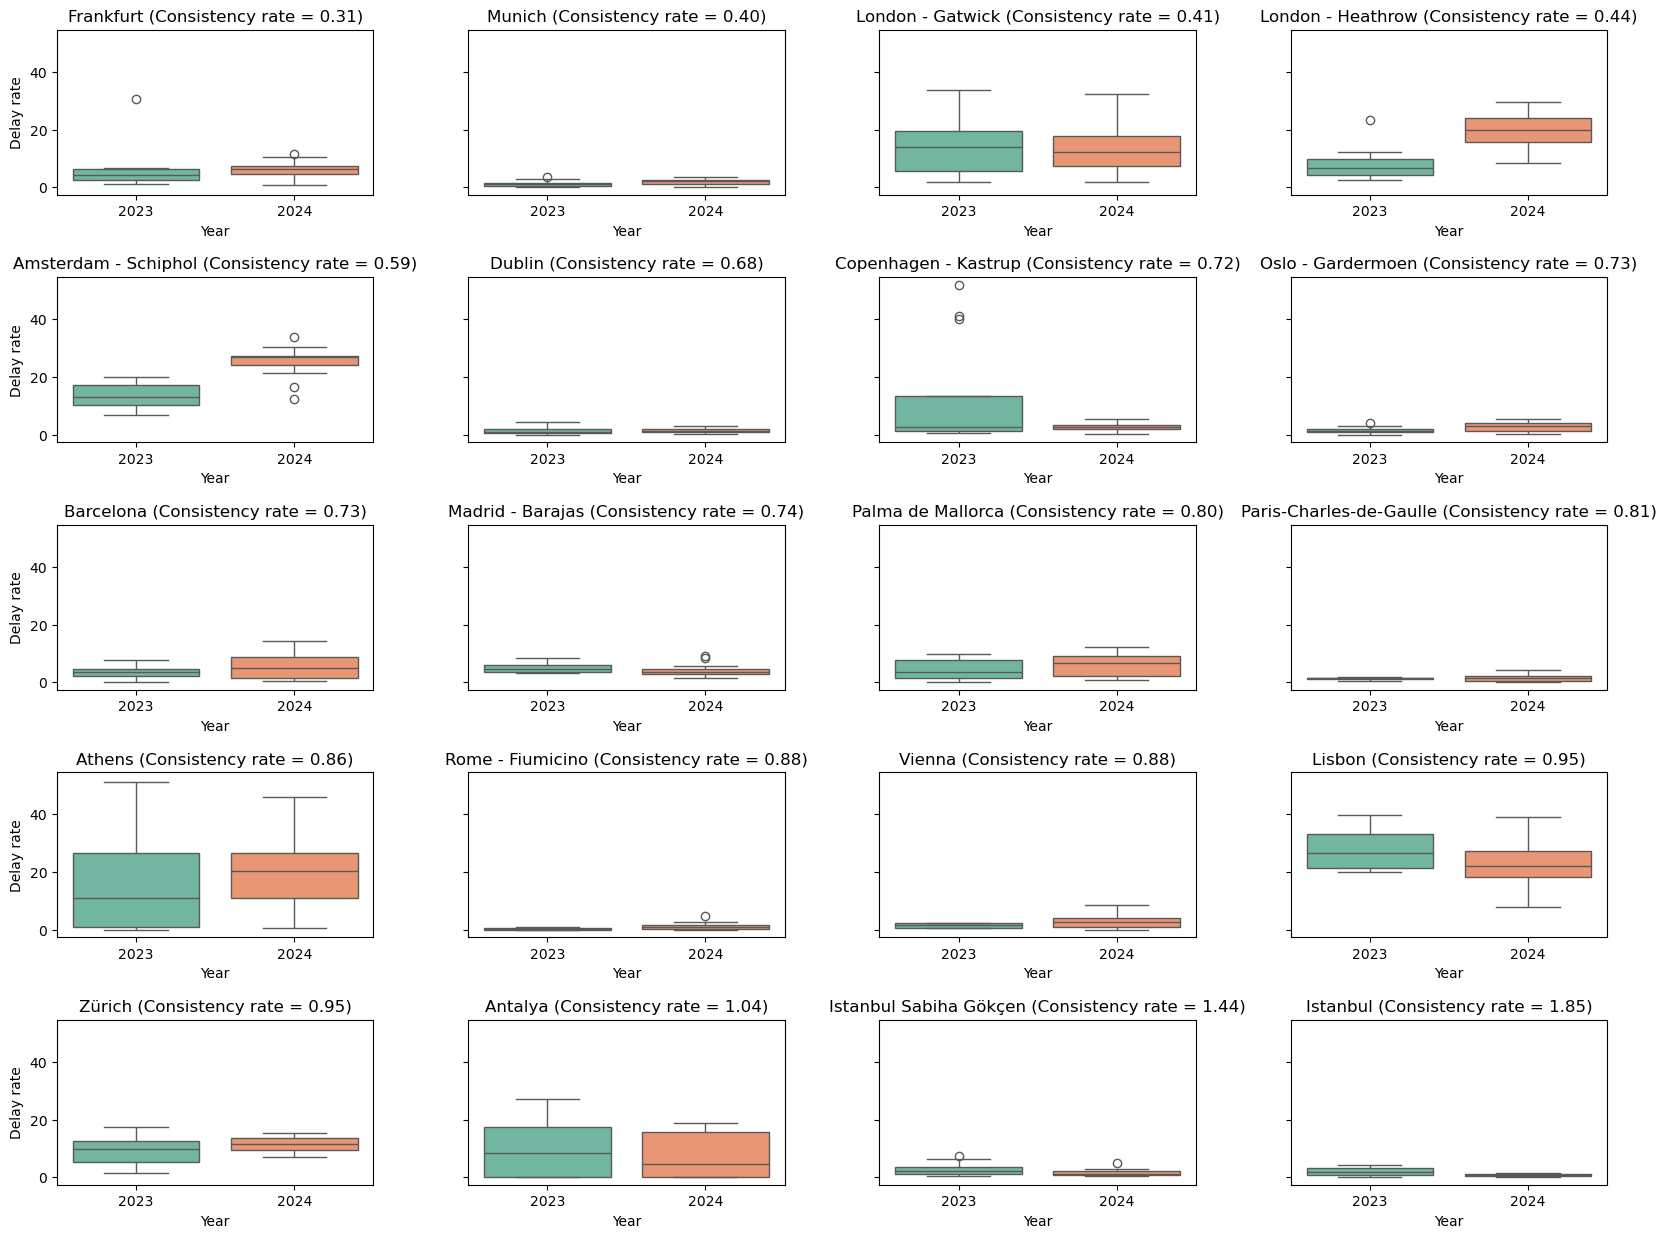

In [38]:
fig_yearly_stats, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 15),
    sharey=True
)

axes = axes.flatten()  

# Loop of airports. For each airport  a boxplot is created.
for i, airport in enumerate(airports):
    ax = axes[i]
    sns.boxplot(
        data=df_with_monthly_delay_rates[df_with_monthly_delay_rates["APT_NAME"] == airport],
        x="YEAR",
        y=("Delay_rate_flights"),
        hue = "YEAR",
        palette="Set2",
        ax=ax,
        legend=False
        )
    cv_value = consistency.iloc[i]["cv"]
    ax.set_title(f"{airport} (Consistency rate = {cv_value:.2f})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Delay rate")  

# Adjust the spacing to create more space between the boxplots.
fig_yearly_stats.subplots_adjust(hspace=0.5, wspace=0.3)

plt.show()

For RQ 3: Suggestions on how to interpret "efficiency":

1. Based on delay rates: the smaller the delay rate, the higher efficiency
a. Proportion of flights
b. Proportion of time 

2. Based on capacity: the higher the amount of flights handled compared to capacity of the airport, the higher efficiency

3. Based on consistency: the more consistent teh delay rates are, the higher efficiency.

4. Based on the context/external factors: consider factors such as weather, infrastructure quality, airspace congestion, political choices, etc. 